In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('diabetic_data.csv')

# Preview data
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Check shape (rows, columns)
df.shape

# Check column names
df.columns

# Check data types
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [4]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Check missing again
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [5]:
# Drop columns with too many missing values
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'], errors='ignore')

In [6]:
# Check readmission values
df['readmitted'].value_counts()


,count
readmitted,
NO,54864
>30,35545
<30,11357


In [7]:
# Convert readmission to binary
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

df['readmitted_binary'].value_counts()

,count
readmitted_binary,
0,90409
1,11357


In [8]:
# Readmission rate
readmission_rate = df['readmitted_binary'].mean()
print("Readmission Rate:", readmission_rate)

Readmission Rate: 0.11159915885462728


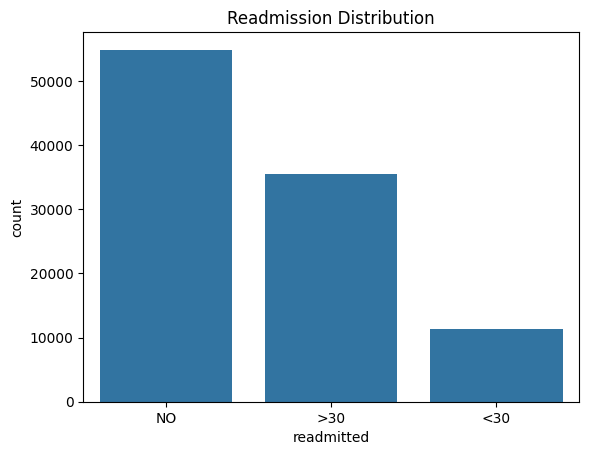

In [9]:
sns.countplot(x='readmitted', data=df)
plt.title('Readmission Distribution')
plt.show()

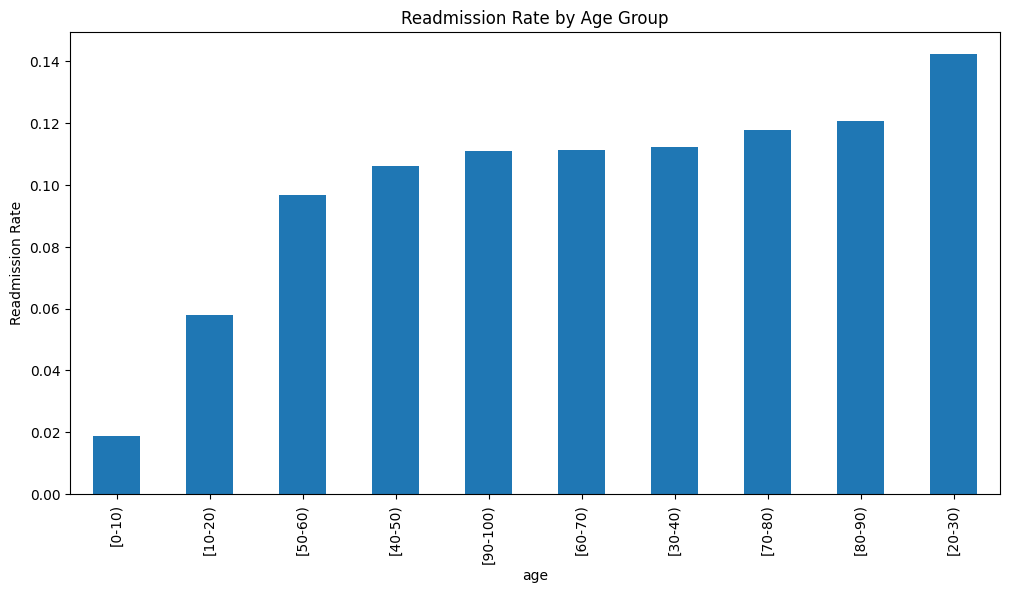

In [10]:
# Readmission by age
age_readmission = df.groupby('age')['readmitted_binary'].mean().sort_values()

age_readmission.plot(kind='bar', figsize=(12,6))
plt.title('Readmission Rate by Age Group')
plt.ylabel('Readmission Rate')
plt.show()

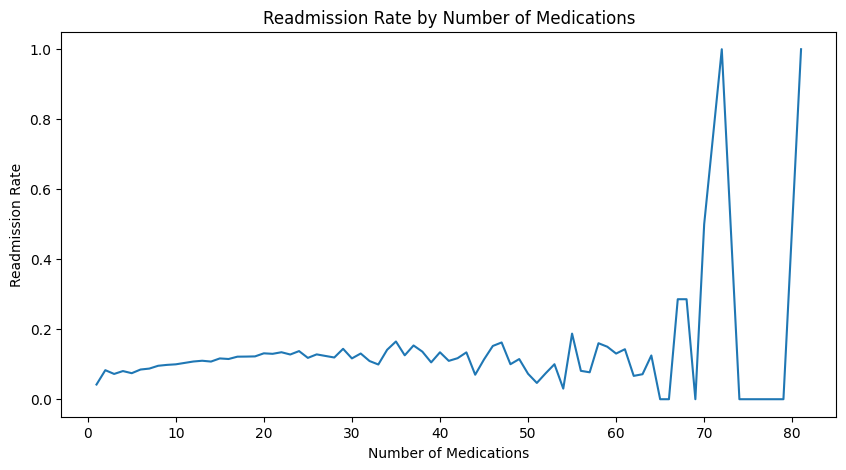

In [11]:
# Readmission by number of medications
med_readmission = df.groupby('num_medications')['readmitted_binary'].mean()

med_readmission.plot(figsize=(10,5))
plt.title('Readmission Rate by Number of Medications')
plt.ylabel('Readmission Rate')
plt.xlabel('Number of Medications')
plt.show()

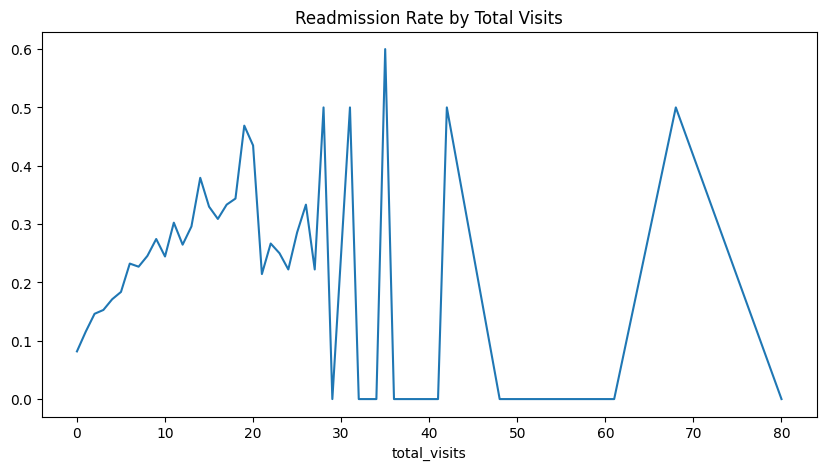

In [12]:
# Total visits
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

visit_readmission = df.groupby('total_visits')['readmitted_binary'].mean()

visit_readmission.plot(figsize=(10,5))
plt.title('Readmission Rate by Total Visits')
plt.show()

Key Insights:


*   Patients aged 20-30 show the highest readmission rates

*   Increased medication count correlates with higher readmission risk

*  Frequent hospital visits strongly predict readmissions


In [13]:
df.to_csv('cleaned_diabetic_data.csv', index=False)